In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
df = pd.read_csv(
    r'C:\Users\dhruv\OneDrive\Desktop\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\data\titanic.csv'
)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:

print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (891, 12)

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Duplicate rows: 0


In [7]:
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates :", rows_after)
print("Duplicates removed             :", rows_before - rows_after)

Rows before removing duplicates: 891
Rows after removing duplicates : 891
Duplicates removed             : 0


In [8]:
X = df.drop("PassengerId", axis=1)
y = df["PassengerId"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (891, 11)
y shape: (891,)

Target distribution:
PassengerId
1      1
2      1
3      1
4      1
5      1
      ..
887    1
888    1
889    1
890    1
891    1
Name: count, Length: 891, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns=["Survived", "PassengerId"])
y = df["Survived"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print(f"Training percentage: {len(X_train) / len(X) * 100:.2f}%")
print(f"Testing percentage: {len(X_test) / len(X) * 100:.2f}%")

Training rows: 712
Testing rows: 179
Training percentage: 79.91%
Testing percentage: 20.09%


In [11]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

Numerical columns: 5
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical columns: 5
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [12]:
missing_count = X_train.isna().sum()
missing_percent = X_train.isna().mean() * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing %", ascending=False)

display(missing_summary)


,Missing Count,Missing %
Cabin,552,77.528090
Age,137,19.241573
Embarked,2,0.280899


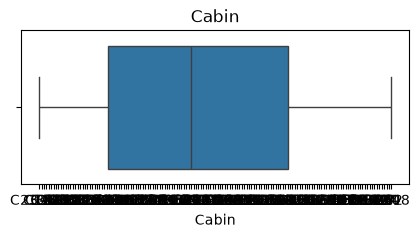

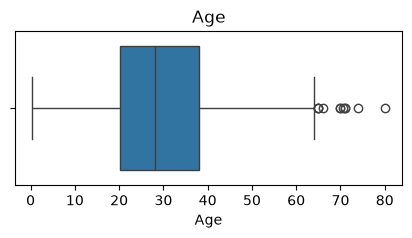

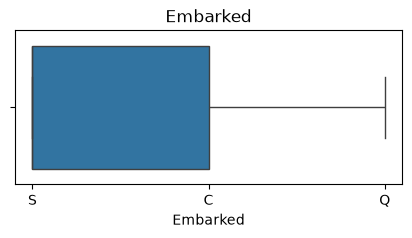

In [13]:
missing_cols=missing_summary.index.tolist()
for col in missing_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[missing_cols][col])
    plt.title(col)
    plt.show()

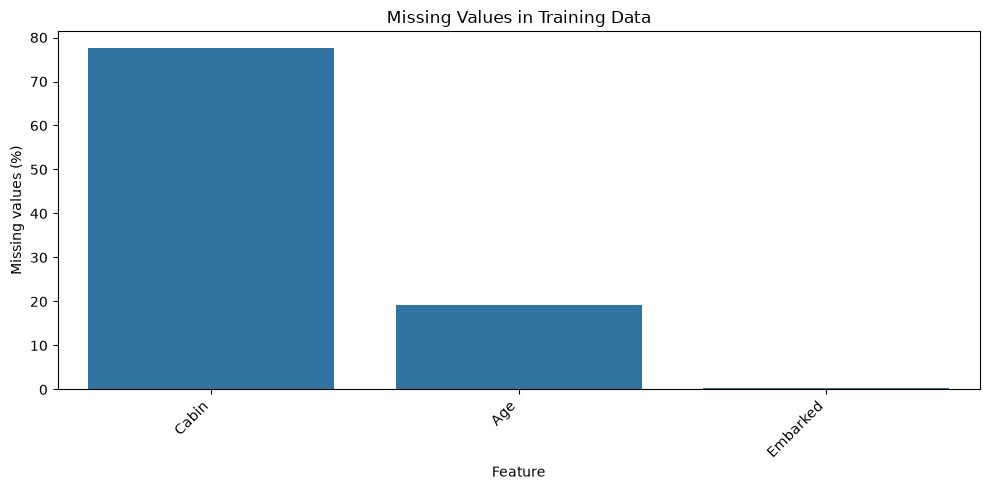

In [14]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing %"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Feature")
plt.ylabel("Missing values (%)")
plt.title("Missing Values in Training Data")
plt.tight_layout()
plt.show()

In [15]:
rows_before = len(X_train)

X_train_without_missing = X_train.dropna()

rows_after = len(X_train_without_missing)

loss = rows_before - rows_after
loss_percent = loss / rows_before * 100

print("Rows before deletion:", rows_before)
print("Rows after deletion :", rows_after)
print("Rows lost           :", loss)
print("Percentage lost     :", round(loss_percent, 2), "%")


Rows before deletion: 712
Rows after deletion : 142
Rows lost           : 570
Percentage lost     : 80.06 %


In [16]:
X_train.shape

(712, 10)

In [17]:
# Create the imputer
numeric_imputer = SimpleImputer(strategy="median")

# STEP 1: Learn medians ONLY from training data
X_train_num = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

# STEP 2: Apply the SAME training medians to test data
X_test_num = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

print("Missing numerical values after imputation:")
print("Training:", X_train_num.isna().sum().sum())
print("Test    :", X_test_num.isna().sum().sum())

Missing numerical values after imputation:
Training: 0
Test    : 0


In [18]:
X_train_num.shape

(712, 5)

In [19]:
missing_numeric_cols = [
    col for col in numeric_cols
    if X_train[col].isna().any()
]

print("Numerical columns with missing values:")
print(missing_numeric_cols)

for col in missing_numeric_cols:
    X_train_num[col + "_missing"] = (
        X_train[col].isna().astype(int)
    )

    X_test_num[col + "_missing"] = (
        X_test[col].isna().astype(int)
    )

print("\nMissing indicators created.")

Numerical columns with missing values:
['Age']

Missing indicators created.


In [20]:
X_train_num

,Pclass,Age,SibSp,Parch,Fare,Age_missing
692,3.0,28.5,0.0,0.0,56.4958,1
481,2.0,28.5,0.0,0.0,0.0000,1
527,1.0,28.5,0.0,0.0,221.7792,1
855,3.0,18.0,0.0,1.0,9.3500,0
801,2.0,31.0,1.0,1.0,26.2500,0
...,...,...,...,...,...,...
359,3.0,28.5,0.0,0.0,7.8792,1
258,1.0,35.0,0.0,0.0,512.3292,0
736,3.0,48.0,1.0,3.0,34.3750,0
462,1.0,47.0,0.0,0.0,38.5000,0


In [21]:
X_train_num.shape

(712, 6)

In [22]:
ordinal_cols = [
    col for col in ["CollegeTier", "CGPA_Tier"]
    if col in X_train.columns
]

# All remaining categorical columns are treated as nominal.
nominal_cols = [
    col for col in categorical_cols
    if col not in ordinal_cols
]

print("Ordinal columns:")
print(ordinal_cols)

print("\nNominal columns:")
print(nominal_cols)

Ordinal columns:
[]

Nominal columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [23]:
for col in nominal_cols:
    print(f"\n{col}")
    print(X_train[col].unique())


Name
<StringArray>
[                                           'Lam, Mr. Ali',
                        'Frost, Mr. Anthony Wood "Archie"',
                                      'Farthing, Mr. John',
                              'Aks, Mrs. Sam (Leah Rosen)',
             'Collyer, Mrs. Harvey (Charlotte Annie Tate)',
                          'Kalvik, Mr. Johannes Halvorsen',
                                          'Lang, Mr. Fang',
                                     'Robbins, Mr. Victor',
                            'McCormack, Mr. Thomas Joseph',
 'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)',
 ...
                          'Gustafsson, Mr. Anders Vilhelm',
                              'Isham, Miss. Ann Elizabeth',
                              'Douglas, Mr. Walter Donald',
                                     'Peters, Miss. Katie',
                                 'Renouf, Mr. Peter Henry',
                       'Mockler, Miss. Helen Mary "Ellie"',
               

In [24]:
from sklearn.preprocessing import OneHotEncoder

# Drop the first category of EACH nominal variable.
# This gives K-1 dummy variables for a variable having K categories.
# It helps avoid the dummy-variable trap / perfect multicollinearity.

nominal_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

# ------------------------------------------------------------
# FIT ON X_train AND TRANSFORM X_train
# ------------------------------------------------------------

nominal_encoded_train = nominal_encoder.fit_transform(
    X_train[nominal_cols]
)

nominal_feature_names = (
    nominal_encoder.get_feature_names_out(nominal_cols)
)

nominal_encoded_train = pd.DataFrame(
    nominal_encoded_train,
    columns=nominal_feature_names,
    index=X_train.index
)

print("\nOne-hot encoded X_train:")
display(nominal_encoded_train.head())

print("\nEncoded nominal feature names:")
print(nominal_feature_names.tolist())

print("\nNumber of nominal features after encoding:",
      nominal_encoded_train.shape[1])


# ------------------------------------------------------------
# TRANSFORM X_test USING THE SAME ENCODER
# ------------------------------------------------------------

nominal_encoded_test = nominal_encoder.transform(
    X_test[nominal_cols]
)

nominal_encoded_test = pd.DataFrame(
    nominal_encoded_test,
    columns=nominal_feature_names,
    index=X_test.index
)

print("\nOne-hot encoded X_test:")
display(nominal_encoded_test.head())

print("\nX_train nominal encoded shape:",
      nominal_encoded_train.shape)

print("X_test nominal encoded shape:",
      nominal_encoded_test.shape)


One-hot encoded X_train:


,"Name_Abbott, Mr. Rossmore Edward","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)","Name_Adahl, Mr. Mauritz Nils Martin","Name_Aks, Mrs. Sam (Leah Rosen)","Name_Albimona, Mr. Nassef Cassem","Name_Alhomaki, Mr. Ilmari Rudolf","Name_Ali, Mr. Ahmed","Name_Ali, Mr. William","Name_Allison, Master. Hudson Trevor",...,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F4,Cabin_G6,Cabin_T,Cabin_nan,Embarked_Q,Embarked_S,Embarked_nan
692,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
481,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
527,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
855,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
801,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0



Encoded nominal feature names:
['Name_Abbott, Mr. Rossmore Edward', 'Name_Abelson, Mr. Samuel', 'Name_Abelson, Mrs. Samuel (Hannah Wizosky)', 'Name_Adahl, Mr. Mauritz Nils Martin', 'Name_Aks, Mrs. Sam (Leah Rosen)', 'Name_Albimona, Mr. Nassef Cassem', 'Name_Alhomaki, Mr. Ilmari Rudolf', 'Name_Ali, Mr. Ahmed', 'Name_Ali, Mr. William', 'Name_Allison, Master. Hudson Trevor', 'Name_Allison, Mrs. Hudson J C (Bessie Waldo Daniels)', 'Name_Allum, Mr. Owen George', 'Name_Andersen-Jensen, Miss. Carla Christine Nielsine', 'Name_Anderson, Mr. Harry', 'Name_Andersson, Master. Sigvard Harald Elias', 'Name_Andersson, Miss. Ebba Iris Alfrida', 'Name_Andersson, Miss. Ellis Anna Maria', 'Name_Andersson, Miss. Erna Alexandra', 'Name_Andersson, Miss. Sigrid Elisabeth', 'Name_Andersson, Mr. Anders Johan', 'Name_Andersson, Mrs. Anders Johan (Alfrida Konstantia Brogren)', 'Name_Andrew, Mr. Edgardo Samuel', 'Name_Andrews, Mr. Thomas Jr', 'Name_Angle, Mrs. William A (Florence "Mary" Agnes Hughes)', 'Name_Arn

c:\Users\dhruv\OneDrive\Desktop\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,"Name_Abbott, Mr. Rossmore Edward","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)","Name_Adahl, Mr. Mauritz Nils Martin","Name_Aks, Mrs. Sam (Leah Rosen)","Name_Albimona, Mr. Nassef Cassem","Name_Alhomaki, Mr. Ilmari Rudolf","Name_Ali, Mr. Ahmed","Name_Ali, Mr. William","Name_Allison, Master. Hudson Trevor",...,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F4,Cabin_G6,Cabin_T,Cabin_nan,Embarked_Q,Embarked_S,Embarked_nan
565,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
553,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0



X_train nominal encoded shape: (712, 1412)
X_test nominal encoded shape: (179, 1412)


In [25]:
nominal_encoded_train.shape

(712, 1412)

In [26]:
label_encoder = LabelEncoder()

# Learn target mapping from training labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Apply the same mapping to test labels
y_test_encoded = label_encoder.transform(y_test)

print("Original target classes:")
print(label_encoder.classes_)

print("\nEncoded target values:")
print(np.unique(y_train_encoded))

Original target classes:
[0 1]

Encoded target values:
[0 1]


In [27]:
if ordinal_cols:
    ordinal_imputer = SimpleImputer(strategy="most_frequent")

    X_train_ord = pd.DataFrame(
        ordinal_imputer.fit_transform(X_train[ordinal_cols]),
        columns=ordinal_cols,
        index=X_train.index
    )

    X_test_ord = pd.DataFrame(
        ordinal_imputer.transform(X_test[ordinal_cols]),
        columns=ordinal_cols,
        index=X_test.index
    )
else:
    X_train_ord = pd.DataFrame(index=X_train.index)
    X_test_ord = pd.DataFrame(index=X_test.index)


# ----- Nominal columns -----
if nominal_cols:
    nominal_imputer = SimpleImputer(strategy="most_frequent")

    X_train_nom = pd.DataFrame(
        nominal_imputer.fit_transform(X_train[nominal_cols]),
        columns=nominal_cols,
        index=X_train.index
    )

    X_test_nom = pd.DataFrame(
        nominal_imputer.transform(X_test[nominal_cols]),
        columns=nominal_cols,
        index=X_test.index
    )
else:
    X_train_nom = pd.DataFrame(index=X_train.index)
    X_test_nom = pd.DataFrame(index=X_test.index)

print("Categorical imputation completed.")

Categorical imputation completed.


In [28]:
X_train_num.shape

(712, 6)

In [29]:
X_train_ord.shape

(712, 0)

In [30]:
nominal_encoded_train.shape

(712, 1412)

In [31]:
X_train_processed = pd.concat(
    [
        X_train_num,
        X_train_ord,        
        nominal_encoded_train

    ],
    axis=1
)

X_test_processed = pd.concat(
    [
        X_test_num,
        X_test_ord,        
        nominal_encoded_test
    ],
    axis=1
)

print("X_train processed shape:", X_train_processed.shape)
print("X_test processed shape :", X_test_processed.shape)

X_train processed shape: (712, 1418)
X_test processed shape : (179, 1418)


In [32]:
scale_cols = [
    col for col in numeric_cols
    if col in X_train_processed.columns
]

scaler = StandardScaler()

# LEARN mean and standard deviation from training data only
X_train_processed[scale_cols] = scaler.fit_transform(
    X_train_processed[scale_cols]
)

# APPLY the same training statistics to test data
X_test_processed[scale_cols] = scaler.transform(
    X_test_processed[scale_cols]
)

print("Standard scaling completed.")

Standard scaling completed.


In [33]:
feature_names = X_train_processed.columns.tolist()

print("Number of features:", len(feature_names))
print("\nFeature names:")
print(feature_names)


Number of features: 1418

Feature names:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Age_missing', 'Name_Abbott, Mr. Rossmore Edward', 'Name_Abelson, Mr. Samuel', 'Name_Abelson, Mrs. Samuel (Hannah Wizosky)', 'Name_Adahl, Mr. Mauritz Nils Martin', 'Name_Aks, Mrs. Sam (Leah Rosen)', 'Name_Albimona, Mr. Nassef Cassem', 'Name_Alhomaki, Mr. Ilmari Rudolf', 'Name_Ali, Mr. Ahmed', 'Name_Ali, Mr. William', 'Name_Allison, Master. Hudson Trevor', 'Name_Allison, Mrs. Hudson J C (Bessie Waldo Daniels)', 'Name_Allum, Mr. Owen George', 'Name_Andersen-Jensen, Miss. Carla Christine Nielsine', 'Name_Anderson, Mr. Harry', 'Name_Andersson, Master. Sigvard Harald Elias', 'Name_Andersson, Miss. Ebba Iris Alfrida', 'Name_Andersson, Miss. Ellis Anna Maria', 'Name_Andersson, Miss. Erna Alexandra', 'Name_Andersson, Miss. Sigrid Elisabeth', 'Name_Andersson, Mr. Anders Johan', 'Name_Andersson, Mrs. Anders Johan (Alfrida Konstantia Brogren)', 'Name_Andrew, Mr. Edgardo Samuel', 'Name_Andrews, Mr. Thomas Jr', 'Na